In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm, freeze_layers

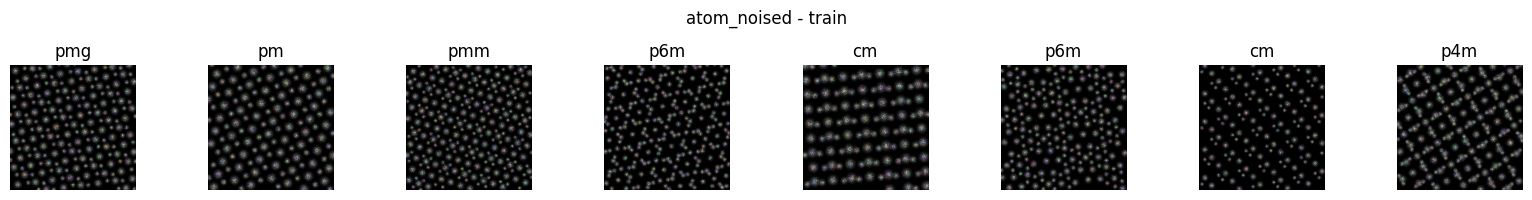

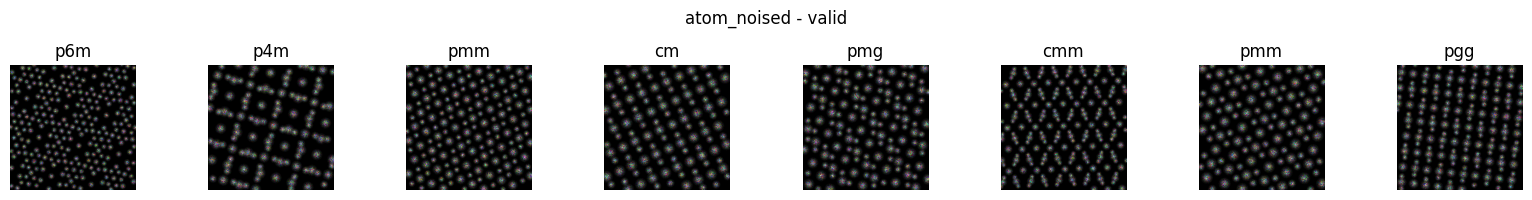

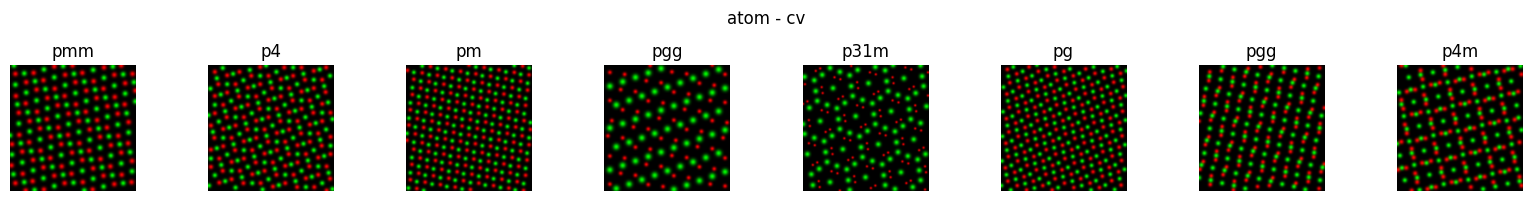

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

atom_noised_ds = hdf5_dataset('../../../datasets/atom_noised_v4_rot_2m.h5', folder='test', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(atom_noised_ds, train_ratio=0.8, seed=42)

# atom_noised - train
train_dl = DataLoader(train_ds, batch_size=5000, shuffle=False, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='atom_noised - train')

# atom_noised - valid
valid_dl = DataLoader(valid_ds, batch_size=5000, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='atom_noised - valid')

# atom - test - 200k subset
cv_atom_ds = hdf5_dataset('../../../datasets/atom_v4_rot_2m_unchunked.h5', folder='test', transform=transforms.ToTensor())
_, cv_atom_ds = split_train_valid(cv_atom_ds, train_ratio=0.8, seed=42)
cv_atom_dl = DataLoader(cv_atom_ds, batch_size=5000, shuffle=False, num_workers=4)
viz_dataloader(cv_atom_dl, label_converter=label_converter, title='atom - cv')

In [3]:
config = {
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

# device = torch.device('cuda:0')
NAME = '02292024-finetune_resnet50_conv1_layer1-atom_noised_2m'

In [4]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [12]:
model = torch.load('../../../saved_models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-20.pt', map_location=torch.device('cpu'))
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

# Freeze the specified layers
target_layers = ['layer2', 'layer3', 'layer4', 'classifier']
freeze_layers(model, target_layers)

def is_layer_frozen(model, layer_name):
    for name, param in model.named_parameters():
        if layer_name in name and param.requires_grad:
            return False
    return True

for layer in ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'classifier']:
    print(f"Is {layer} frozen? {is_layer_frozen(model, layer)}")

model = torch.nn.DataParallel(model, device_ids=[0,1,2,3,4,5,6,7])
device = torch.device('cuda:0')

torch.Size([2, 17])
Is conv1 frozen? False
Is layer1 frozen? False
Is layer2 frozen? True
Is layer3 frozen? True
Is layer4 frozen? True
Is classifier frozen? True


In [13]:
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_atom_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/321 [00:00<?, ?it/s]

100%|██████████| 321/321 [11:31<00:00,  2.16s/it]


Training: Loss: 7.0608, Accuracy: 50.0060%, Time: 11.5307mins


100%|██████████| 81/81 [02:06<00:00,  1.56s/it]


...

Training: Loss: 0.0601, Accuracy: 97.9941%, Time: 9.3797mins


100%|██████████| 81/81 [01:40<00:00,  1.25s/it]


Validation : Loss : 0.0447, Accuracy: 98.3811%, Time: 1.68mins


100%|██████████| 82/82 [01:39<00:00,  1.22s/it]


Validation : Loss : 1.0053, Accuracy: 73.9947%, Time: 1.66mins
